<a href="https://colab.research.google.com/github/PavanRishi69/dataviz-exercises-pavan-rishi-gillella/blob/main/lecture11_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 11 — Multi-Page & Multi-tab Streamlit Apps


> **Dataset:** Gapminder

> **Big Book of Dashboards:** Ch.36 The Squiggle + Ch.5 Executive Sales Dashboard


---
## Opening: Model Answer Review


---
## Design Principles - Part I: Analytical Dashboards


### Dashboards answer known questions — the squiggle finds unknown ones

> **💡 A Key Performance Indicator (KPI) tells you WHAT --> Clicking into it asks WHY --> Drilling further asks WHY AGAIN**

> **💡 A well-designed analytical dashboard supports this chain of questions by having a structure that goes from summary → trend → detail**

**Example from the [Superstore Dataset](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final) [example dashboard](https://medium.com/@itsfangying/road-to-data-analyst-3-building-dashboard-for-superstore-in-excel-b8693e48d46):**
1. KPI shows overall profit is fine ← the dashboard answers this
2. Click into by-category shows furniture is struggling ← a second Page 2 needed
3. Scatter of individual orders shows discounting is causing losses ← Page 3 needed
4. Root cause: 20%+ discounts on tables always result in a loss

> **This is why you are encouraged to create multi-page dashboard in your final project — because no real-world question is answered at one level of granularity**

### 💡 Analytical dashboard page structure (BBD Ch.5)

| Page | Title (question-based) | Granularity |
|---|---|---|
| 1 | How do countries compare today? | Summary snapshot |
| 2 | How has life expectancy changed? | Trend over time |
| 3 | What explains the differences? | Individual country drill-down |



### Multi-page folder structure

```
app.py          ← entry point, defines navigation
utils.py        ← @st.cache_data data loading — shared across all pages
pages/
  01_overview.py
  02_trends.py
  03_compare.py
requirements.txt
```

> **Put the @st.cache_data function in utils.py and import it in every page. The cache key is the function — so the same data load is reused across all pages without reloading from disk on each page visit**

### `st.tabs()` — lightweight in-page navigation

```python
tab1, tab2 = st.tabs(['GDP vs Life Expectancy', 'Population vs Life Expectancy'])
with tab1:
    st.plotly_chart(fig1, use_container_width=True)
with tab2:
    st.plotly_chart(fig2, use_container_width=True)
```

**💡 When to use tab and pages:**

- **Use tabs for:** related views the user switches between frequently
  
- **Use pages for:** distinct questions at different levels of granularity

### `st.session_state` — values that persist across *reruns and pages*

```python
# Page 3: remember which country the user selected
if 'highlight_country' not in st.session_state:
    st.session_state.highlight_country = 'China'  # initialise once

st.session_state.highlight_country = st.selectbox(
    'Highlight country',
    countries,
    index=countries.index(st.session_state.highlight_country)
)
# Now if the user changes country and switches tabs, the selection persists
```


---
## Let's Code An Example Dashboard 💻

> **HOW TO RUN:**

> Build file by file: utils.py → app.py → pages/01 → pages/02 → pages/03
>
> Show each page in the browser as you build it


In [1]:
import pandas as pd
import plotly.express as px


df = px.data.gapminder()

df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


---
## Transition to Exercise

> 1. Build a 3-page Gapminder app. Create `app.py`, `utils.py`, `pages/` folder
> 2. Push the whole folder to week11/ in your classwork repo

**BBD + Streamlit checklist:**
- Page titles are questions (not 'Overview', 'Trends', 'Analysis')
- The 3 pages represent summary → trend → detail (the squiggle)
- `utils.py` with `@st.cache_data`
- `st.session_state` used on at least one page
- `st.tabs()` used on at least one page
- Colour type named in a comment on each chart


---
# Completed Exercise — Gapminder Dashboard Analysis

The following cells use the supplied `gapminder(1).csv` dataset and show the results required for the three dashboard questions: **summary → exploration → comparison**.

In [3]:
# Task 1: Load and inspect the supplied dataset
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_PATH = "/content/gapminder (1).csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head())

Dataset shape: 47 rows × 6 columns


,Country,Continent,GDP_per_capita,Life_expectancy,Population,CO2_per_capita
0,Afghanistan,Asia,550,63,38000000,0.3
1,Australia,Oceania,54000,83,26000000,15.1
2,Bangladesh,Asia,2200,73,170000000,0.5
3,Brazil,Americas,8900,76,215000000,2.1
4,Canada,Americas,46000,82,38000000,14.2


In [4]:
# Check column types and missing values
summary = pd.DataFrame({
    "Data type": df.dtypes.astype(str),
    "Missing values": df.isna().sum(),
    "Unique values": df.nunique()
})
display(summary)

,Data type,Missing values,Unique values
Country,object,0,47
Continent,object,0,5
GDP_per_capita,int64,0,39
Life_expectancy,int64,0,22
Population,int64,0,39
CO2_per_capita,float64,0,34


## Page 1 — How do countries compare today?

This page provides a high-level summary using KPIs and a bubble chart. The chart uses **categorical colour** for continent.

In [5]:
# KPI results
richest = df.loc[df["GDP_per_capita"].idxmax()]
highest_life = df.loc[df["Life_expectancy"].idxmax()]
largest_pop = df.loc[df["Population"].idxmax()]

kpis = pd.DataFrame({
    "KPI": ["Countries", "Average life expectancy", "Richest country", "Highest life expectancy", "Most populous country"],
    "Result": [
        len(df),
        f"{df['Life_expectancy'].mean():.1f} years",
        f"{richest['Country']} (${richest['GDP_per_capita']:,.0f})",
        f"{highest_life['Country']} ({highest_life['Life_expectancy']} years)",
        f"{largest_pop['Country']} ({largest_pop['Population']:,.0f})"
    ]
})
display(kpis)

,KPI,Result
0,Countries,47
1,Average life expectancy,73.7 years
2,Richest country,"Norway ($82,000)"
3,Highest life expectancy,Japan (84 years)
4,Most populous country,"China (1,400,000,000)"


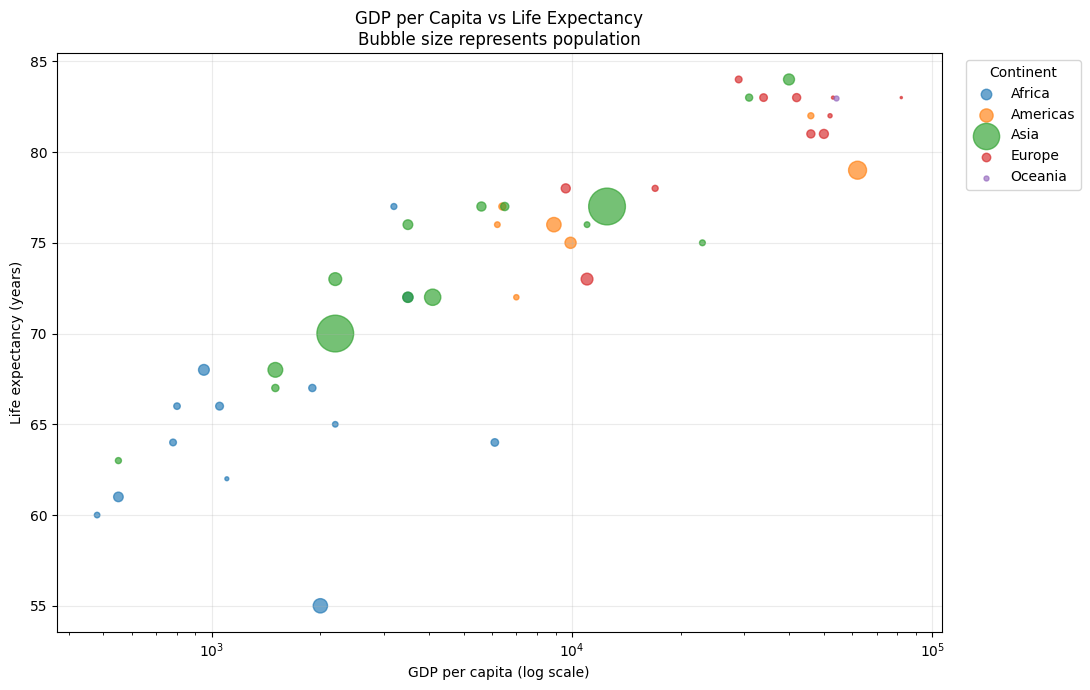

In [6]:
# Bubble chart: GDP per capita vs life expectancy
fig, ax = plt.subplots(figsize=(11, 7))
for continent, group in df.groupby("Continent"):
    ax.scatter(
        group["GDP_per_capita"], group["Life_expectancy"],
        s=group["Population"] / 2_000_000, alpha=0.65, label=continent
    )
ax.set_xscale("log")
ax.set_xlabel("GDP per capita (log scale)")
ax.set_ylabel("Life expectancy (years)")
ax.set_title("GDP per Capita vs Life Expectancy\nBubble size represents population")
ax.legend(title="Continent", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [8]:
# Top 10 countries by GDP per capita
top_gdp = df.nlargest(10, "GDP_per_capita")[["Country", "Continent", "GDP_per_capita", "Life_expectancy"]]
display(top_gdp.reset_index(drop=True))

,Country,Continent,GDP_per_capita,Life_expectancy
0,Norway,Europe,82000,83
1,USA,Americas,62000,79
2,Australia,Oceania,54000,83
3,Sweden,Europe,53000,83
4,Netherlands,Europe,52000,82
5,Germany,Europe,50000,81
6,Canada,Americas,46000,82
7,UK,Europe,46000,81
8,France,Europe,42000,83
9,Japan,Asia,40000,84


## Page 2 — What patterns exist across continents?

This page explores continent-level patterns. The charts use **categorical colour** to distinguish continents.

In [9]:
# Continent-level summary
continent_summary = (
    df.groupby("Continent")
      .agg(
          Countries=("Country", "count"),
          Average_GDP_per_capita=("GDP_per_capita", "mean"),
          Average_life_expectancy=("Life_expectancy", "mean"),
          Total_population=("Population", "sum"),
          Average_CO2_per_capita=("CO2_per_capita", "mean")
      )
      .round(2)
      .sort_values("Average_life_expectancy", ascending=False)
)
display(continent_summary)

,Countries,Average_GDP_per_capita,Average_life_expectancy,Total_population,Average_CO2_per_capita
Continent,,,,,
Oceania,1,54000.00,83.00,26000000,15.10
Europe,11,38690.91,80.82,627000000,6.43
Americas,7,20914.29,76.71,831000000,5.94
Asia,15,9910.00,74.00,4171000000,5.07
Africa,13,1893.08,65.15,915000000,1.02


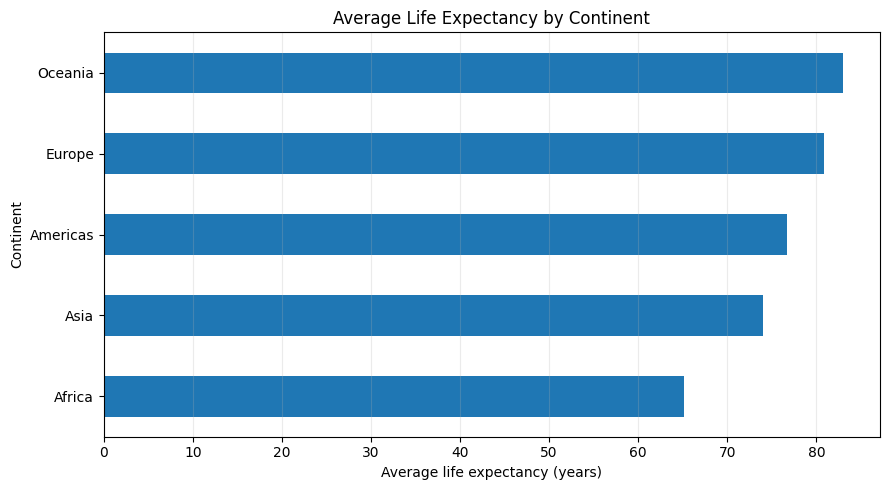

In [10]:
# Average life expectancy by continent
plot_data = continent_summary.sort_values("Average_life_expectancy")
ax = plot_data["Average_life_expectancy"].plot(kind="barh", figsize=(9, 5))
ax.set_xlabel("Average life expectancy (years)")
ax.set_ylabel("Continent")
ax.set_title("Average Life Expectancy by Continent")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

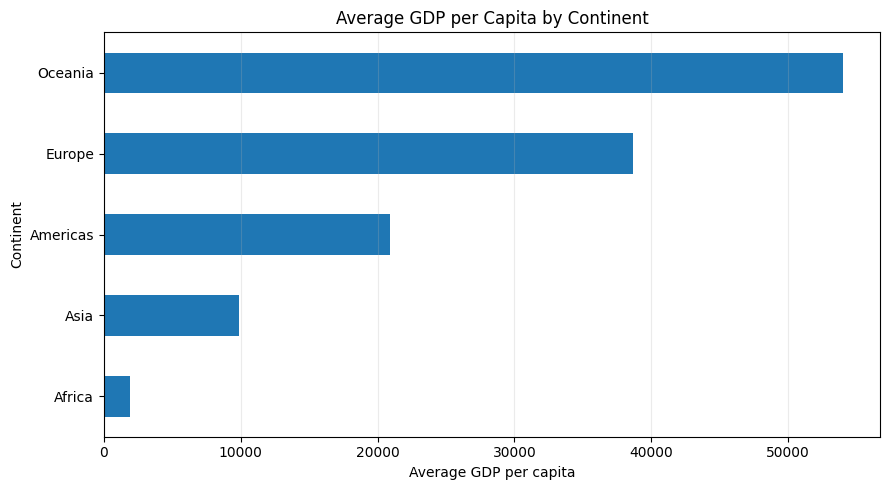

In [11]:
# Average GDP and CO2 by continent
fig, ax = plt.subplots(figsize=(9, 5))
continent_summary.sort_values("Average_GDP_per_capita")["Average_GDP_per_capita"].plot(kind="barh", ax=ax)
ax.set_xlabel("Average GDP per capita")
ax.set_ylabel("Continent")
ax.set_title("Average GDP per Capita by Continent")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Page 3 — What explains the differences?

This page drills down to selected countries and compares their economic, health, population, and emissions indicators. The bar charts use **categorical colour** for each metric.

In [12]:
# Compare two example countries: Germany and India
selected_countries = ["Germany", "India"]
comparison = df[df["Country"].isin(selected_countries)].set_index("Country")
display(comparison)

,Continent,GDP_per_capita,Life_expectancy,Population,CO2_per_capita
Country,,,,,
Germany,Europe,50000,81,84000000,7.7
India,Asia,2200,70,1400000000,1.9


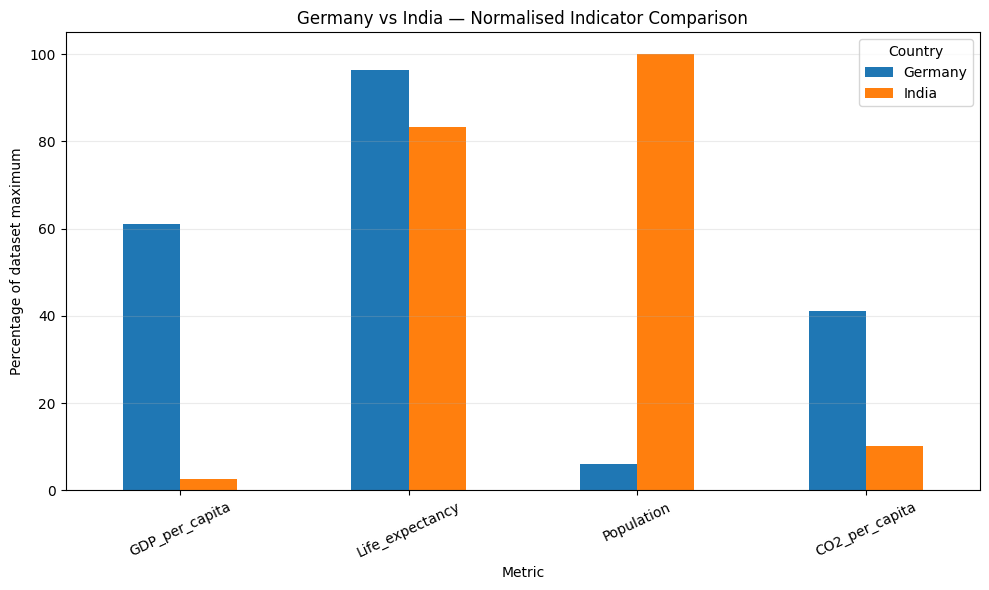

,GDP_per_capita,Life_expectancy,Population,CO2_per_capita
Country,,,,
Germany,61.0,96.4,6.0,41.2
India,2.7,83.3,100.0,10.2


In [13]:
# Normalised comparison makes indicators with different units comparable
metrics = ["GDP_per_capita", "Life_expectancy", "Population", "CO2_per_capita"]
normalised = comparison[metrics].copy()
normalised = normalised.div(df[metrics].max(), axis=1) * 100
normalised = normalised.round(1)

ax = normalised.T.plot(kind="bar", figsize=(10, 6))
ax.set_ylabel("Percentage of dataset maximum")
ax.set_xlabel("Metric")
ax.set_title("Germany vs India — Normalised Indicator Comparison")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

display(normalised)

In [14]:
# Correlation analysis: relationships that may explain differences
correlation = df[["GDP_per_capita", "Life_expectancy", "Population", "CO2_per_capita"]].corr().round(3)
display(correlation)

print("GDP–Life Expectancy correlation:", correlation.loc["GDP_per_capita", "Life_expectancy"])
print("GDP–CO2 correlation:", correlation.loc["GDP_per_capita", "CO2_per_capita"])

,GDP_per_capita,Life_expectancy,Population,CO2_per_capita
GDP_per_capita,1.000,0.733,-0.118,0.644
Life_expectancy,0.733,1.000,-0.035,0.603
Population,-0.118,-0.035,1.000,-0.003
CO2_per_capita,0.644,0.603,-0.003,1.000


GDP–Life Expectancy correlation: 0.733
GDP–CO2 correlation: 0.644


## Main Findings

1. Countries with higher GDP per capita generally have higher life expectancy, although the relationship becomes less steep among high-income countries.
2. Average outcomes vary strongly across continents, particularly for GDP, life expectancy, and CO₂ emissions.
3. Population size is not a direct measure of prosperity: highly populated countries can have much lower GDP per capita than smaller countries.
4. GDP per capita and CO₂ emissions tend to move together in this dataset, suggesting that wealthier economies often have higher emissions per person.
5. A multi-page dashboard is appropriate because it allows users to move from overall KPIs, to continent patterns, and finally to detailed country comparisons.